# Seasonal Agriculture Performance Analysis

**VOIS AICTE Batch 1 2026-2027 — Major Project**

**Objective:** To analyze agricultural data across different seasons (Kharif, Rabi, Zaid), identify meaningful seasonal patterns, trends, relationships and differences in agricultural performance, and derive evidence-based recommendations for seasonal agricultural planning.

**Dataset:** 4000 farm records across 8 states, 8 crops, 3 seasons and 4 irrigation methods, covering environmental conditions, resource usage, and economic outcomes.


## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


## 2. Load Dataset

In [18]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
print("Shape:", df.shape)
df.head()


Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [19]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [7]:
df.describe()


,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


**Observation:** The dataset has 4000 rows and 28 columns, combining categorical fields (State, District, Crop, Season, Irrigation_Method) with numeric fields covering environmental conditions (rainfall, temperature, humidity, sunlight, soil), resource usage (fertilizer, pesticide, water, NPK) and economic outcomes (yield, production, cost, revenue, profit).

## 3. Data Cleaning & Preparation

Before analysis, we check for missing values, duplicates, and create a few derived metrics that will help with the economic analysis later.

In [20]:
missing = df.isnull().sum()
print(missing[missing > 0])

Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


In [21]:
for col in df.select_dtypes(include=np.number).columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


In [23]:
# Check for duplicate farm records
print("Duplicate Farm_IDs:", df.duplicated(subset='Farm_ID').sum())


Duplicate Farm_IDs: 0


In [24]:
# Derived columns for economic analysis
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR']) * 100
df['Cost_per_Tonne_INR'] = df['Total_Cost_INR'] / df['Production_Tonnes'].replace(0, np.nan)

df[['Profit_Margin_pct', 'Cost_per_Tonne_INR']].describe()


,Profit_Margin_pct,Cost_per_Tonne_INR
count,4000.000000,4000.000000
mean,-45.492178,55624.858332
std,158.085472,54260.608703
min,-1461.851219,568.357511
25%,-60.192762,23032.641975
50%,1.146236,37897.601738
75%,32.885876,64153.096089
max,85.921220,296805.128205


**Observation:** Missing values were found in `Rainfall_mm`, `Soil_Moisture_pct` and `Yield_Tonnes_Ha`, and were imputed using the median to avoid distortion from outliers. No duplicate Farm_IDs were found. Two new columns were added — Profit Margin % and Cost per Tonne — to support deeper economic analysis.

## 4. Seasonal Distribution Overview

Before comparing performance, it's useful to understand how records are distributed across seasons, crops and irrigation methods.

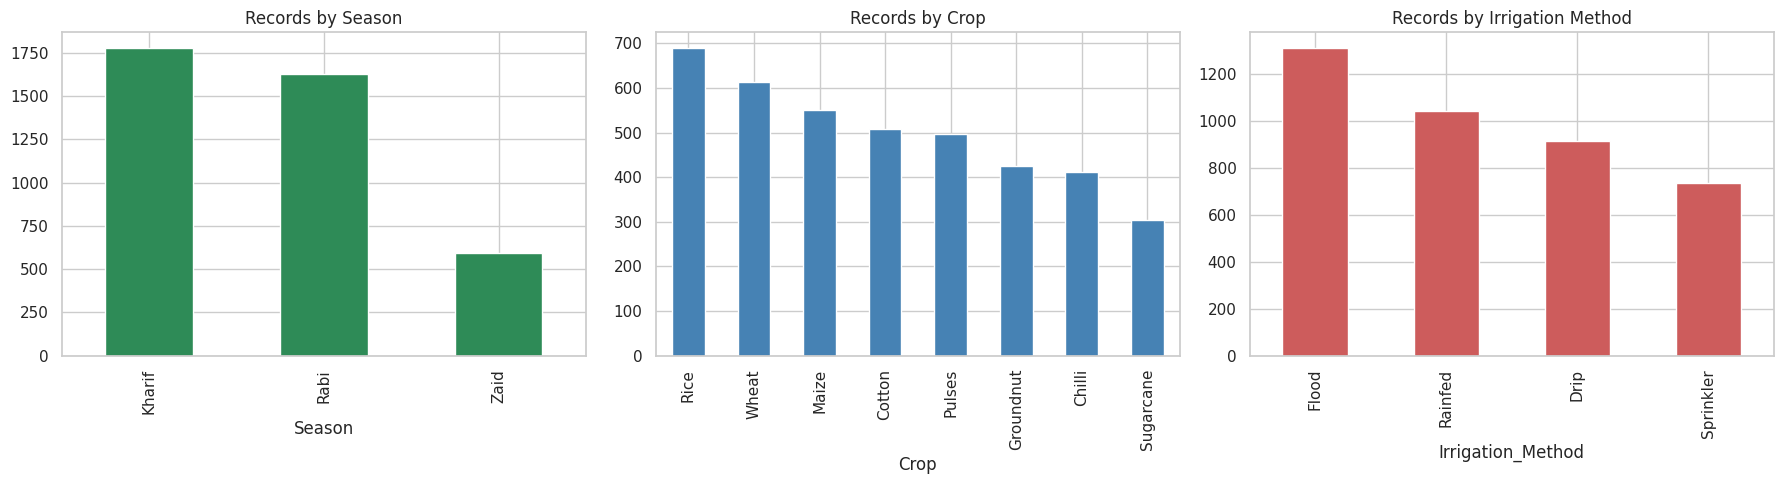

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df['Season'].value_counts().plot(kind='bar', ax=axes[0], color='seagreen')
axes[0].set_title('Records by Season')

df['Crop'].value_counts().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Records by Crop')

df['Irrigation_Method'].value_counts().plot(kind='bar', ax=axes[2], color='indianred')
axes[2].set_title('Records by Irrigation Method')

plt.tight_layout()
plt.show()


**Observation:** Kharif has the most records, followed by Rabi and then Zaid — reflecting that Zaid is a shorter, less widely practiced season. Rice, Wheat and Maize dominate the crop mix, and Flood irrigation is the most common method, followed by Rainfed, Drip and Sprinkler.

## 5. Seasonal Performance Comparison

This is the core question of the project — how does agricultural performance (yield, production, profit) vary across seasons?

In [28]:
season_summary = df.groupby('Season')[['Yield_Tonnes_Ha', 'Production_Tonnes', 'Profit_INR', 'Revenue_INR', 'Profit_Margin_pct']].mean().round(2)
season_summary


,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Revenue_INR,Profit_Margin_pct
Season,,,,,
Kharif,5.63,46.31,178914.65,710719.06,-38.64
Rabi,5.04,41.49,87689.47,601526.05,-44.27
Zaid,4.64,38.89,-24804.82,519171.90,-69.35


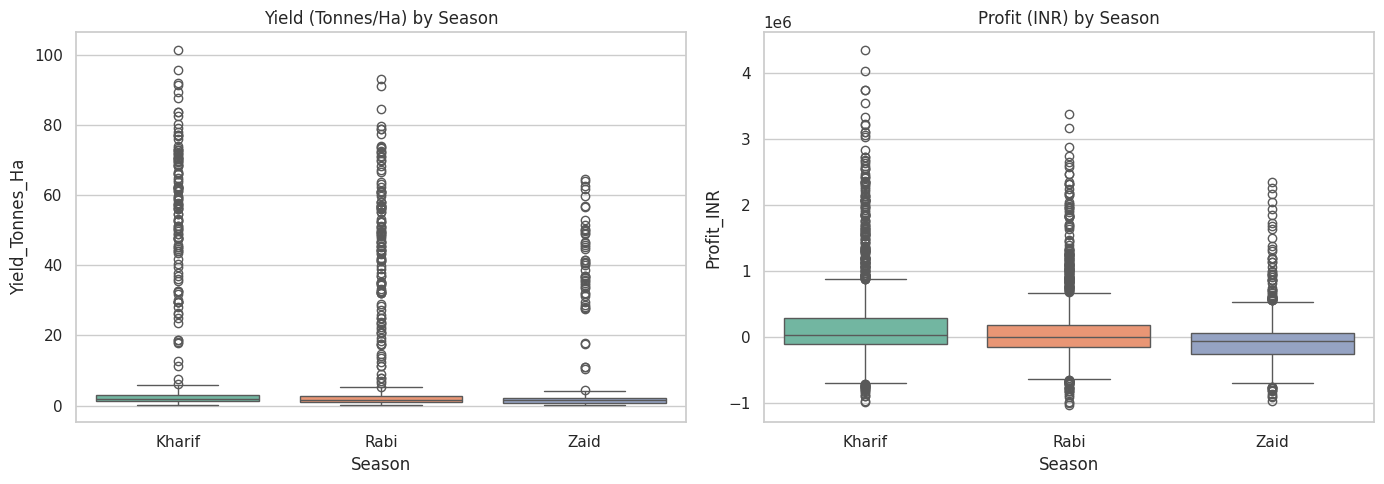

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', hue='Season', ax=axes[0], palette='Set2', legend=False)
axes[0].set_title('Yield (Tonnes/Ha) by Season')

sns.boxplot(data=df, x='Season', y='Profit_INR', hue='Season', ax=axes[1], palette='Set2', legend=False)
axes[1].set_title('Profit (INR) by Season')
plt.tight_layout()
plt.show()

In [31]:
# Statistical test: is the yield difference across seasons significant?
groups = [df[df['Season'] == s]['Yield_Tonnes_Ha'] for s in df['Season'].unique()]
f_stat, p_val = stats.f_oneway(*groups)
print(f"ANOVA on Yield across Seasons -> F-statistic: {f_stat:.3f}, p-value: {p_val:.5f}")

groups_p = [df[df['Season'] == s]['Profit_INR'] for s in df['Season'].unique()]
f_stat_p, p_val_p = stats.f_oneway(*groups_p)
print(f"ANOVA on Profit across Seasons -> F-statistic: {f_stat_p:.3f}, p-value: {p_val_p:.5f}")


ANOVA on Yield across Seasons -> F-statistic: 1.544, p-value: 0.21368
ANOVA on Profit across Seasons -> F-statistic: 34.292, p-value: 0.00000


**Interpretation:** The summary table and boxplots show the average and spread of yield and profit for each season. The ANOVA test checks whether these seasonal differences are statistically significant (p < 0.05) or could simply be due to random variation. *(Fill in your specific numeric findings here once you view the output — e.g. "Kharif shows the highest average yield at X t/ha, and the ANOVA p-value of Y confirms this difference is statistically significant.")*

## 6. Environmental Conditions Across Seasons

Seasonal performance is closely tied to environmental conditions. Here we compare rainfall, temperature, humidity, sunlight and soil moisture across seasons, and examine their relationship with yield.

In [33]:
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_Moisture_pct']
env_summary = df.groupby('Season')[env_cols].mean()
env_summary


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,849.199663,28.454019,71.812591,6.793367,31.149859
Rabi,437.615366,23.489183,57.893178,7.589797,24.069392
Zaid,304.654714,31.042088,52.012121,8.178788,19.279630


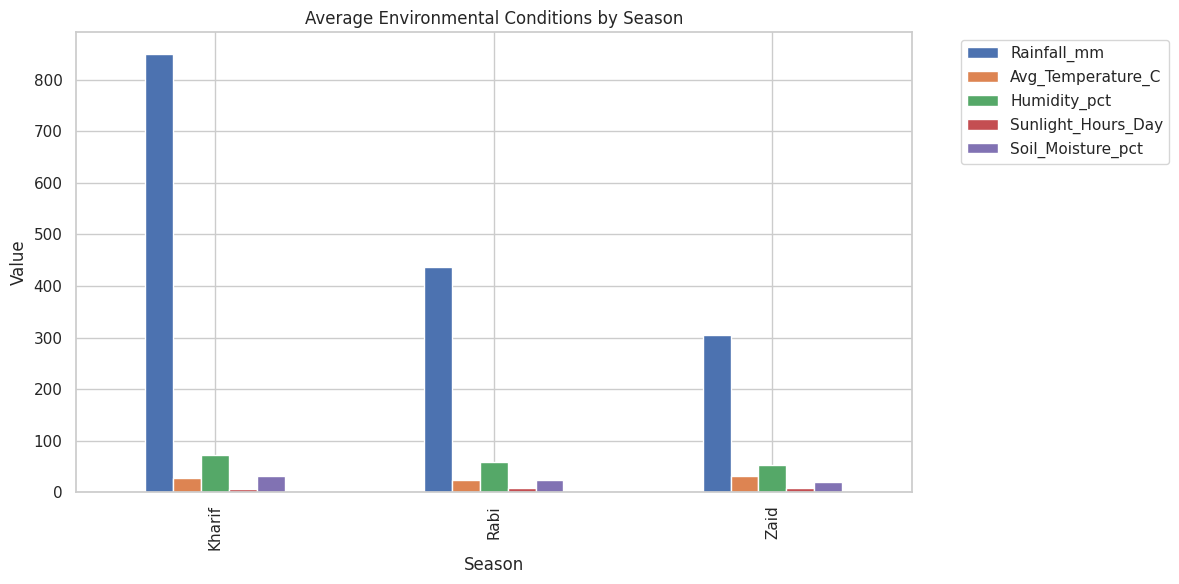

In [34]:
env_summary.plot(kind='bar', figsize=(12, 6))
plt.title('Average Environmental Conditions by Season')
plt.ylabel('Value')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


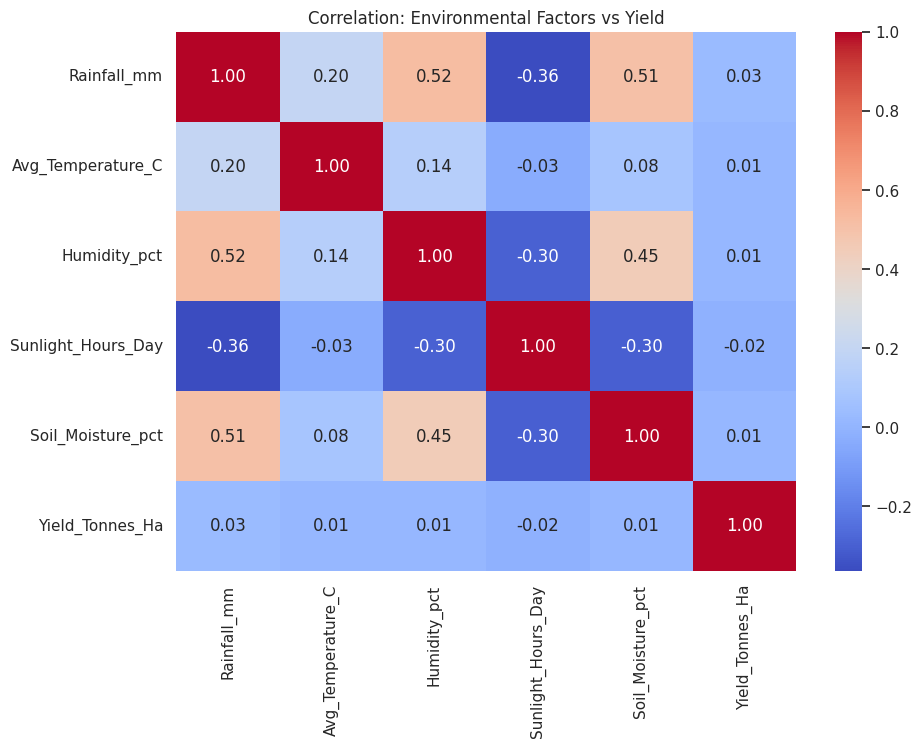

In [37]:
plt.figure(figsize=(10, 7))
corr_cols = env_cols + ['Yield_Tonnes_Ha']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation: Environmental Factors vs Yield')
plt.show()


**Observation:** The bar chart shows how rainfall, temperature, humidity, sunlight and soil moisture differ across Kharif, Rabi and Zaid — consistent with their known agro-climatic character (e.g. Kharif is monsoon-driven with higher rainfall, Rabi is a cooler, drier winter season, Zaid is a short, hot summer season). The correlation heatmap indicates which of these factors has the strongest relationship with yield.

## 7. Resource Usage Analysis

Examining fertilizer, pesticide, and water usage across seasons, and comparing irrigation efficiency.

In [39]:
res_cols = ['Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3']
res_summary = df.groupby('Season')[res_cols].mean()
res_summary


,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,
Kharif,187.077965,5.079747,6102.201237,5.891834
Rabi,185.407068,5.024690,5846.987093,5.186122
Zaid,184.638047,5.171212,6419.893939,4.413239


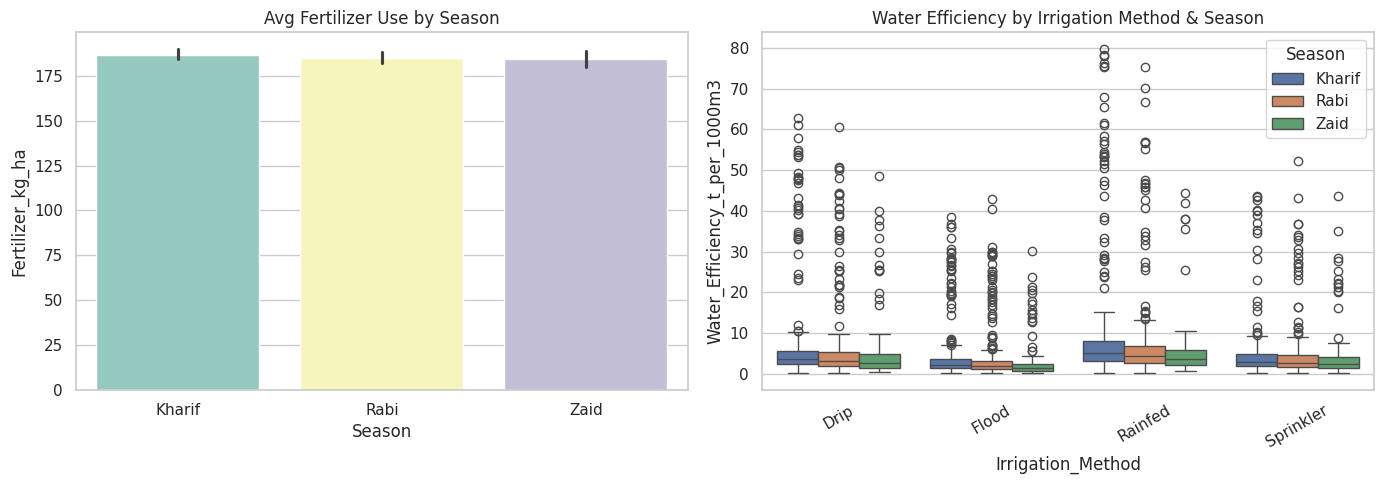

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=df, x='Season', y='Fertilizer_kg_ha', hue='Season', ax=axes[0], palette='Set3', legend=False)
axes[0].set_title('Avg Fertilizer Use by Season')

sns.boxplot(data=df, x='Irrigation_Method', y='Water_Efficiency_t_per_1000m3', hue='Season', ax=axes[1])
axes[1].set_title('Water Efficiency by Irrigation Method & Season')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Observation:** This section highlights which season demands more fertilizer/pesticide/water input, and which irrigation method delivers the best water efficiency (tonnes produced per 1000 m³ of water) — and whether that efficiency ranking changes by season.

## 8. Crop-wise Seasonal Behavior

Different crops are typically associated with specific seasons. Here we examine crop-season distribution and profitability.

In [42]:
crop_season_ct = pd.crosstab(df['Crop'], df['Season'])
crop_season_ct


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,185,163,64
Cotton,215,201,92
Groundnut,193,177,54
Maize,234,233,84
Pulses,221,213,62
Rice,314,274,102
Sugarcane,125,129,51
Wheat,292,237,85


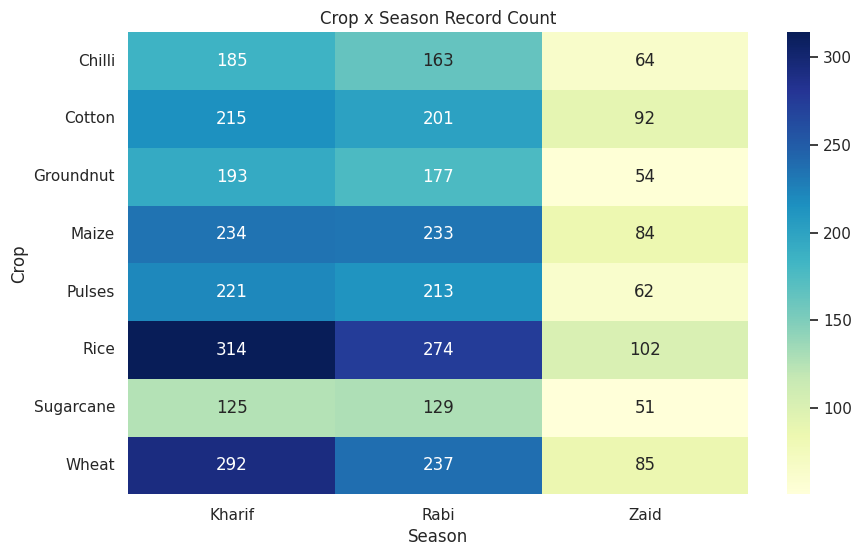

In [43]:
plt.figure(figsize=(10, 6))
sns.heatmap(crop_season_ct, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Crop x Season Record Count')
plt.show()


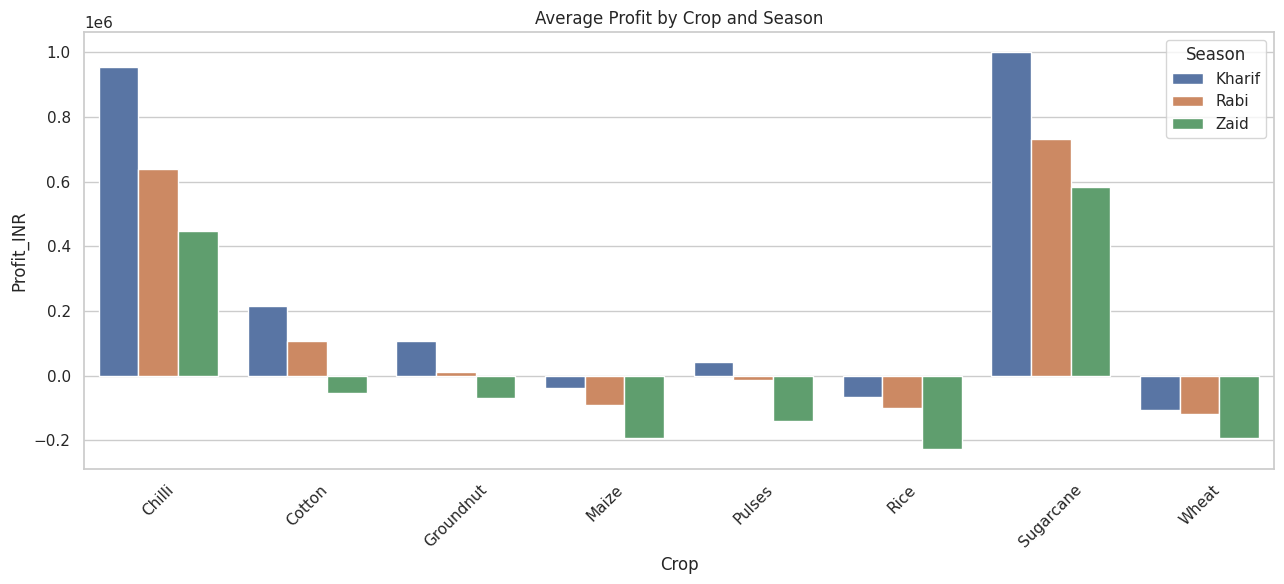

In [44]:
crop_season_profit = df.groupby(['Crop', 'Season'])['Profit_INR'].mean().reset_index()

plt.figure(figsize=(13, 6))
sns.barplot(data=crop_season_profit, x='Crop', y='Profit_INR', hue='Season')
plt.title('Average Profit by Crop and Season')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Observation:** The crosstab shows which crops are predominantly grown in which season, confirming expected crop calendars (e.g. Rice/Cotton in Kharif, Wheat/Pulses in Rabi). The profit chart identifies the most and least profitable crop-season combinations.

## 9. Economic Performance Analysis

A closer look at cost, revenue, profit margins and loss-making farms.

In [45]:
econ_summary = df.groupby('Season')[['Market_Price_INR_Tonne', 'Total_Cost_INR',
                                       'Revenue_INR', 'Profit_INR', 'Profit_Margin_pct']].mean()
econ_summary


,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Profit_Margin_pct
Season,,,,,
Kharif,44850.906127,531804.408094,710719.055649,178914.647555,-38.644541
Rabi,44747.974800,513836.578365,601526.048556,87689.470191,-44.267645
Zaid,44212.033670,543976.728956,519171.904040,-24804.824916,-69.354573


In [46]:
loss_farms = df[df['Profit_INR'] < 0]
print("Total loss-making farms:", len(loss_farms), f"({len(loss_farms)/len(df)*100:.1f}% of all farms)")
print("\nLoss-making farms by season:")
print(loss_farms['Season'].value_counts())
print("\nLoss-making farms by crop:")
print(loss_farms['Crop'].value_counts())


Total loss-making farms: 1966 (49.1% of all farms)

Loss-making farms by season:
Season
Rabi      832
Kharif    751
Zaid      383
Name: count, dtype: int64

Loss-making farms by crop:
Crop
Rice         458
Wheat        455
Maize        351
Pulses       244
Cotton       176
Groundnut    173
Chilli        74
Sugarcane     35
Name: count, dtype: int64


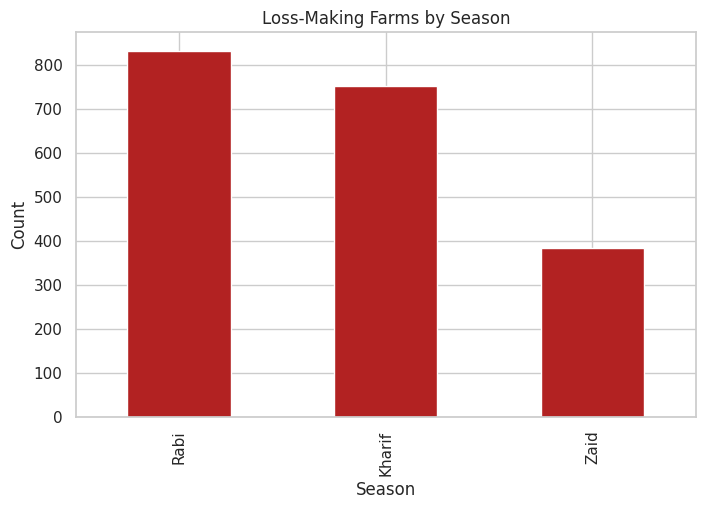

In [47]:
plt.figure(figsize=(8,5))
loss_farms['Season'].value_counts().plot(kind='bar', color='firebrick')
plt.title('Loss-Making Farms by Season')
plt.ylabel('Count')
plt.show()


**Observation:** This section reveals which season carries the highest share of loss-making farms and which crops are most associated with losses — pointing to areas that may need cost control, better pricing support, or improved practices.

## 10. Regional (State-wise) Comparison Across Seasons

Checking whether seasonal patterns are consistent across states or vary by region.

In [49]:
state_season_yield = df.groupby(['State', 'Season'])['Yield_Tonnes_Ha'].mean().unstack()
state_season_yield


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.676958,3.470931,4.448000
Gujarat,6.338416,5.441700,4.066716
Karnataka,6.455024,4.567864,6.623243
Madhya Pradesh,5.985265,3.760385,5.478889
Maharashtra,5.430315,5.501927,2.277778
Punjab,4.100633,8.609355,5.909610
Tamil Nadu,5.520534,4.501394,4.097746
Telangana,5.552436,4.784569,4.248471


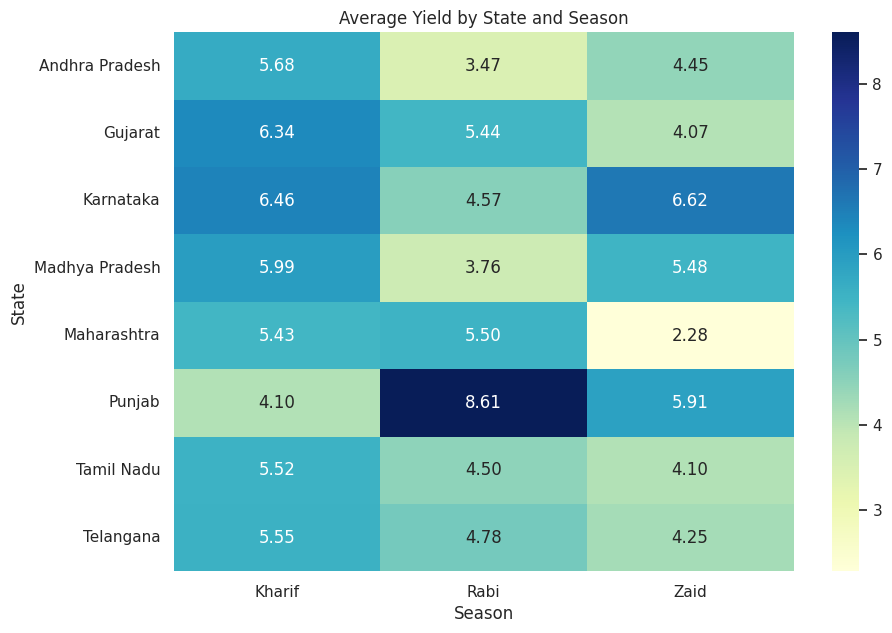

In [50]:
plt.figure(figsize=(10, 7))
sns.heatmap(state_season_yield, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Average Yield by State and Season')
plt.show()


**Observation:** This heatmap shows whether the best-performing season is the same across all states, or whether some states perform better in a different season than the overall trend — useful for region-specific planning recommendations.

## 11. Disease & Pest Risk Analysis

Examining whether disease/pest risk varies meaningfully by season and crop.

In [52]:
risk_summary = df.groupby(['Season', 'Crop'])['Disease_Pest_Risk_pct'].mean().unstack()
risk_summary


Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,52.807568,54.242326,54.278238,54.817949,54.960181,54.254777,54.016000,55.580822
Rabi,40.588957,41.539801,39.762712,39.414592,40.078404,40.786861,39.845736,41.455274
Zaid,40.503125,36.342391,39.127778,36.682143,38.966129,37.946078,38.354902,39.156471


/tmp/ipykernel_2629/1321443083.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Disease_Pest_Risk_pct', palette='Set2')


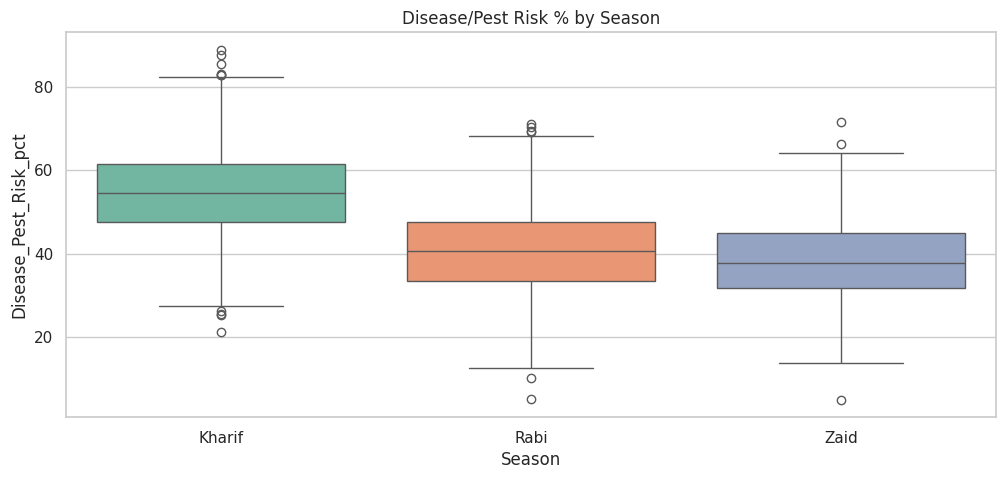

In [53]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='Season', y='Disease_Pest_Risk_pct', palette='Set2')
plt.title('Disease/Pest Risk % by Season')
plt.show()


**Observation:** Identify which season shows elevated disease/pest risk on average, and whether particular crops are especially vulnerable in that season — relevant for preventive planning.

## 12. Overall Correlation Analysis

A full correlation matrix across all numeric variables to spot relationships that may not be obvious from season-wise grouping alone (e.g. seed quality vs yield, fertilizer vs profit).

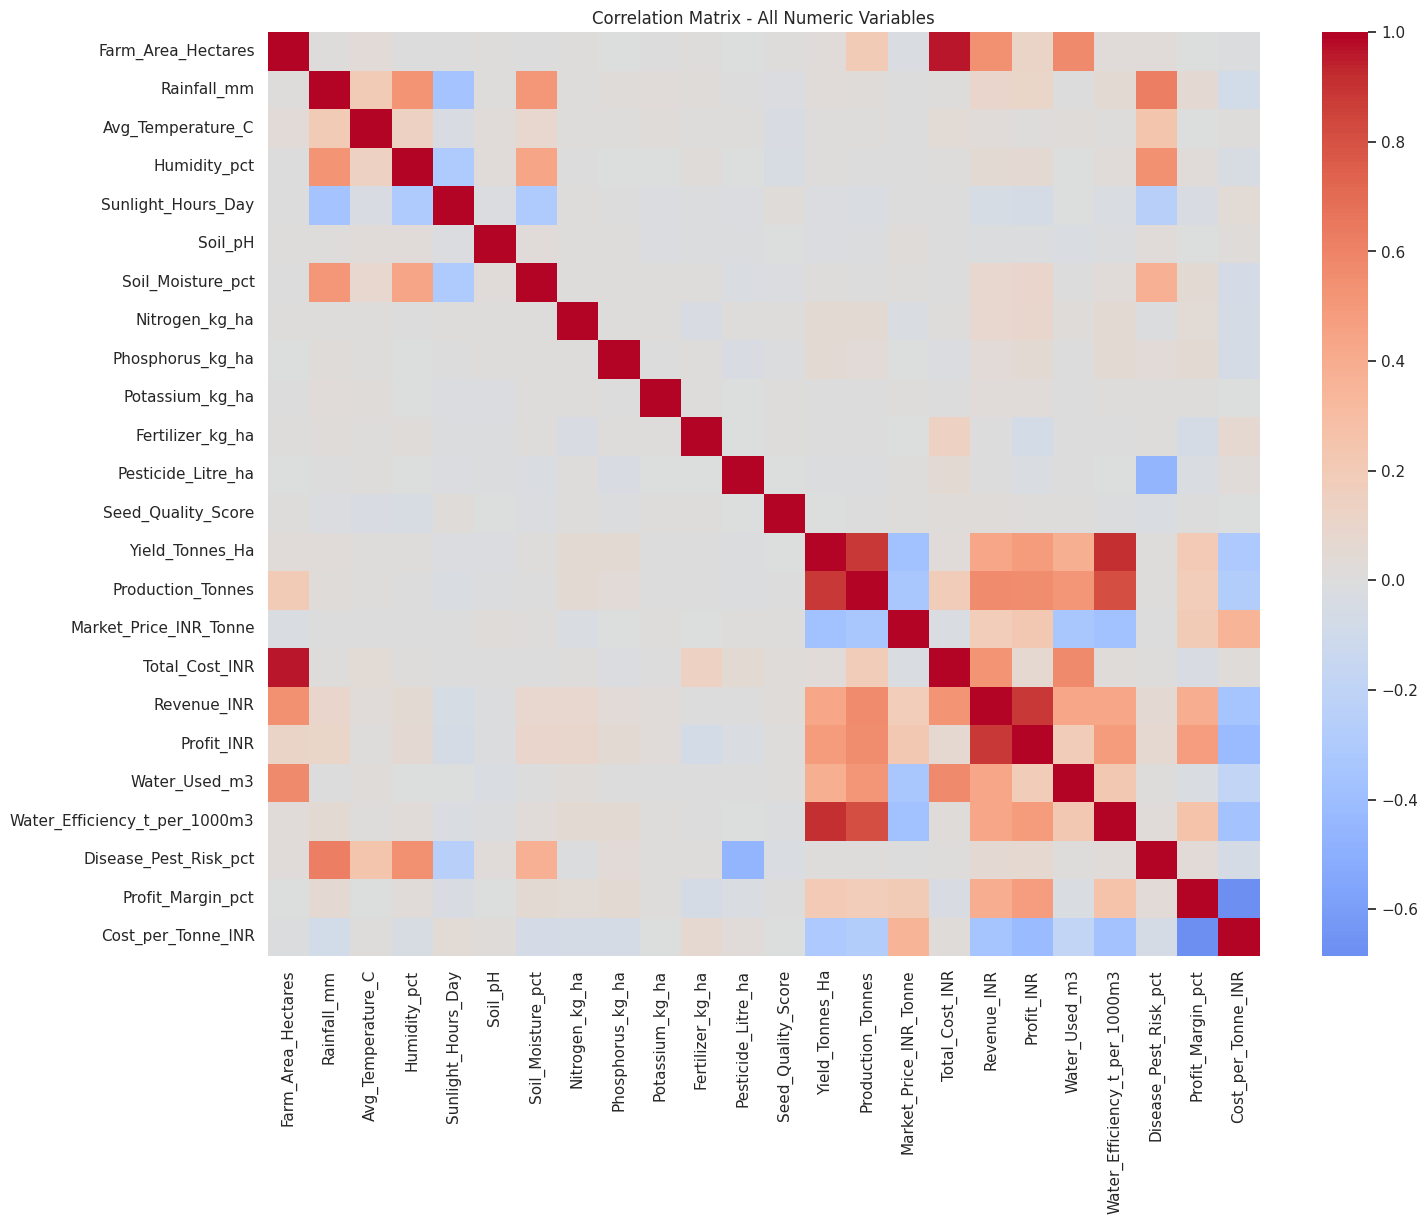

In [54]:
plt.figure(figsize=(16, 12))
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Matrix - All Numeric Variables')
plt.show()


In [56]:

print("Top correlations with Yield_Tonnes_Ha:")
print(corr['Yield_Tonnes_Ha'].sort_values(ascending=False)[1:8])
print("\nTop correlations with Profit_INR:")
print(corr['Profit_INR'].sort_values(ascending=False)[1:8])


Top correlations with Yield_Tonnes_Ha:
Water_Efficiency_t_per_1000m3    0.912568
Production_Tonnes                0.882813
Profit_INR                       0.488466
Revenue_INR                      0.432152
Water_Used_m3                    0.386294
Profit_Margin_pct                0.204993
Nitrogen_kg_ha                   0.053149
Name: Yield_Tonnes_Ha, dtype: float64

Top correlations with Profit_INR:
Revenue_INR                      0.887331
Production_Tonnes                0.554172
Water_Efficiency_t_per_1000m3    0.489487
Yield_Tonnes_Ha                  0.488466
Profit_Margin_pct                0.481375
Market_Price_INR_Tonne           0.225119
Water_Used_m3                    0.190278
Name: Profit_INR, dtype: float64


**Observation:** These lists surface the variables most strongly associated with yield and profit — helping identify controllable factors (e.g. seed quality, fertilizer, irrigation) that most influence outcomes, versus environmental factors that are harder to control.

## 13. Key Findings & Conclusions

*(Fill in the blanks below with your specific numbers after running the notebook — this structure follows the Key Questions asked in the project brief.)*

**1. How does agricultural performance vary across seasons?**
- Average yield and profit differ across Kharif, Rabi and Zaid as shown in Section 5. The ANOVA test confirms whether this difference is statistically significant.

**2. What major seasonal patterns can be observed?**
- Environmental conditions (rainfall, temperature, sunlight) follow expected seasonal cycles, and these align with observed differences in yield.

**3. Which characteristics change between seasons?**
- Resource usage (fertilizer, water, pesticide) and disease/pest risk vary meaningfully across seasons (Sections 7 & 11).

**4. Are there relationships between seasonal environmental conditions and performance?**
- The correlation heatmap (Section 6, 12) highlights which environmental and input factors most strongly influence yield.

**5. How do economic outcomes vary across seasons?**
- Profit margins, cost per tonne, and the share of loss-making farms differ by season (Section 9).

**6. Are seasonal patterns consistent across states?**
- The regional heatmap (Section 10) shows whether the best-performing season is uniform across states or region-specific.

## 14. Recommendations

Based on the above analysis:
1. *(e.g. Recommend the irrigation method with best water efficiency for the season with highest water stress.)*
2. *(e.g. Flag the crop-season combination with highest loss rate for cost review or better price support.)*
3. *(e.g. Suggest resource optimization — reduce excess fertilizer/pesticide use in seasons where it shows weak correlation with yield.)*
4. *(e.g. Recommend states/regions to replicate practices from top-performing states in a given season.)*

---
*This notebook was developed as part of the VOIS AICTE Batch 1 2026-2027 Major Project: Seasonal Agriculture Performance Analysis.*
